## Data Preparation: Loading and Initial Exploration

In [1]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the zip file
zip_file_path = '/content/UCI Heart Disease Data.zip'

# Directory to extract the contents to
extract_dir = '/content/heart_disease_data/'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted data to: {extract_dir}")


Extracted data to: /content/heart_disease_data/


The dataset is now extracted. Let's find the CSV file within the extracted directory and load it into a pandas DataFrame. Based on typical UCI datasets, it's likely a `.csv` file.

In [2]:
import os

# List files in the extracted directory to find the data file
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.csv'):
            csv_file_path = os.path.join(root, file)
            print(f"Found CSV file: {csv_file_path}")
            break
    if 'csv_file_path' in locals():
        break

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(csv_file_path)
    print("Dataset loaded successfully!")
    display(df.head())
except Exception as e:
    print(f"Error loading dataset: {e}")


Found CSV file: /content/heart_disease_data/heart_disease_uci.csv
Dataset loaded successfully!


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Now that the data is loaded, let's perform some initial exploratory data analysis (EDA) to understand its structure and content. This includes checking the data types, missing values, and a summary of descriptive statistics.

In [3]:
# Display basic information about the DataFrame
display(df.info())

# Display descriptive statistics
display(df.describe())

# Check for missing values
display(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


None

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


## Data Preprocessing: Handling Missing Values

In [4]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_cols.tolist())
print("Numerical Columns:", numerical_cols.tolist())

# Display unique values and their counts for categorical columns to understand them better
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts(dropna=False))

# Also check unique values for 'ca' and 'thal' even though they are currently float64 and object, respectively
# and have many missing values. It's good to see their full range.
print("\nUnique values in ca:")
print(df['ca'].value_counts(dropna=False))
print("\nUnique values in thal:")
print(df['thal'].value_counts(dropna=False))


Categorical Columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical Columns: ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']

Unique values in sex:
sex
Male      726
Female    194
Name: count, dtype: int64

Unique values in dataset:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

Unique values in cp:
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

Unique values in fbs:
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

Unique values in restecg:
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

Unique values in exang:
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

Unique values in slope:
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Na

Upon examining the unique values, we can see that some columns that are currently `object` type (like `cp`, `restecg`, `exang`, `slope`, `thal`, `fbs`, `sex`, `dataset`) are indeed categorical. The `ca` column, though numerical, seems to represent categories (0, 1, 2, 3) and has a large number of missing values (NaN). The `num` column is our target variable, indicating the presence of heart disease (0 for no disease, >0 for disease).

Let's refine the missing value imputation strategy:
*   **For numerical columns (`trestbps`, `chol`, `thalch`, `oldpeak`):** Impute with the median, as it's more robust to outliers than the mean.
*   **For categorical columns (`fbs`, `restecg`, `exang`, `slope`, `thal`):** Impute with the mode.
*   **For `ca`:** Given its categorical nature (0, 1, 2, 3), we will treat `NaN` as a separate category, or impute with mode, depending on further analysis. For now, let's impute with mode, which is 0.0, to maintain its numerical type for potential encoding later.

Before imputation, it's good practice to ensure `num` is treated as a binary target. The problem statement implies predicting 'if a patient suffers or not', meaning 0 for no disease and 1 for presence. Currently, `num` has values 0, 1, 2, 3, 4. We will convert this to a binary target where any value > 0 becomes 1.

In [5]:
# Convert 'num' to a binary target variable (0: no disease, 1: disease)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Drop the original 'num' column and 'id' as it's an identifier
df = df.drop(columns=['num', 'id', 'dataset'])

# Impute missing numerical values with the median
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# Impute missing categorical values with the mode
for col in ['fbs', 'restecg', 'exang', 'slope', 'thal', 'ca']:
    if df[col].isnull().any():
        # Convert 'ca' to object type before imputing with mode if it still has NaNs and was float
        # This handles the case where 'ca' might be interpreted as float due to NaNs initially
        if col == 'ca' and df[col].dtype == 'float64':
            df[col] = df[col].astype(str).replace('nan', pd.NA)
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed missing values in '{col}' with mode: {mode_val}")

# Verify that there are no more missing values
print("\nMissing values after imputation:")
display(df.isnull().sum())

display(df.head())


Imputed missing values in 'trestbps' with median: 130.0
Imputed missing values in 'chol' with median: 223.0
Imputed missing values in 'thalch' with median: 140.0
Imputed missing values in 'oldpeak' with median: 0.5
Imputed missing values in 'fbs' with mode: False
Imputed missing values in 'restecg' with mode: normal
Imputed missing values in 'exang' with mode: False
Imputed missing values in 'slope' with mode: flat
Imputed missing values in 'thal' with mode: normal
Imputed missing values in 'ca' with mode: 0.0

Missing values after imputation:


/tmp/ipykernel_7270/1060537411.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Data Preprocessing: Encoding Categorical Variables and Feature Scaling

In [6]:
# Identify categorical columns to be one-hot encoded (excluding 'target')
categorical_cols_for_encoding = df.select_dtypes(include='object').columns.tolist()

print(f"Categorical columns to one-hot encode: {categorical_cols_for_encoding}")

# Apply one-hot encoding to the identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols_for_encoding, drop_first=True)

print("\nDataFrame after one-hot encoding:")
display(df_encoded.head())
print(f"Shape after encoding: {df_encoded.shape}")


Categorical columns to one-hot encode: ['sex', 'cp', 'restecg', 'slope', 'ca', 'thal']

DataFrame after one-hot encoding:


,age,trestbps,chol,fbs,thalch,exang,oldpeak,target,sex_Male,cp_atypical angina,...,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0,True,False,...,True,False,False,False,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,1,True,False,...,False,False,False,True,False,False,False,True,True,False
2,67,120.0,229.0,False,129.0,True,2.6,1,True,False,...,False,False,False,True,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0,False,True,...,False,False,False,False,True,False,False,False,True,False


Shape after encoding: (920, 21)


Now that the categorical features are encoded, we will apply feature scaling to the numerical columns. This is important for many machine learning algorithms, including Logistic Regression, to prevent features with larger values from dominating the learning process.

In [7]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Identify numerical columns for scaling (all columns in X except the encoded ones, which are already binary/0,1)
# The original numerical columns are 'age', 'trestbps', 'chol', 'thalch', 'oldpeak'
# The 'ca' column was also numerical, but we treated it as categorical for imputation
# Let's re-identify numerical columns based on dtypes in X

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Numerical features to scale: {numerical_features.tolist()}")

# Apply StandardScaler to numerical features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print("\nFeatures after scaling:")
display(X.head())

print("\nPreprocessing complete. Ready for model training!")


Numerical features to scale: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

Features after scaling:


,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
0,1.007386,0.705176,0.303643,True,0.489727,False,1.368109,True,False,False,True,False,False,False,False,False,False,False,False,False
1,1.432034,1.518569,0.789967,False,-1.181478,True,0.611589,True,False,False,False,False,False,True,False,False,False,True,True,False
2,1.432034,-0.650479,0.266939,False,-0.345875,True,1.651804,True,False,False,False,False,False,True,False,False,True,False,False,True
3,-1.752828,-0.108217,0.459634,False,1.961979,False,2.502889,True,False,True,False,True,False,False,False,False,False,False,True,False
4,-1.328180,-0.108217,0.037541,False,1.365120,False,0.517024,False,True,False,False,False,False,False,True,False,False,False,True,False



Preprocessing complete. Ready for model training!


## Model Training: Logistic Regression

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully!")

# Evaluate the model using cross-validation
cv_scores = cross_val_score(log_reg_model, X, y, cv=5, scoring='accuracy')
print(f"\nCross-validation Accuracy Scores: {cv_scores}")
print(f"Mean Cross-validation Accuracy: {cv_scores.mean():.4f}")


X_train shape: (736, 20)
X_test shape: (184, 20)
y_train shape: (736,)
y_test shape: (184,)

Logistic Regression model trained successfully!

Cross-validation Accuracy Scores: [0.79891304 0.72826087 0.88043478 0.84782609 0.68478261]
Mean Cross-validation Accuracy: 0.7880


## Model Evaluation

Accuracy: 0.8478
Precision: 0.8491
Recall: 0.8824
F1-Score: 0.8654

Confusion Matrix:


,Predicted No Disease,Predicted Disease
Actual No Disease,66,16
Actual Disease,12,90



Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        82
           1       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



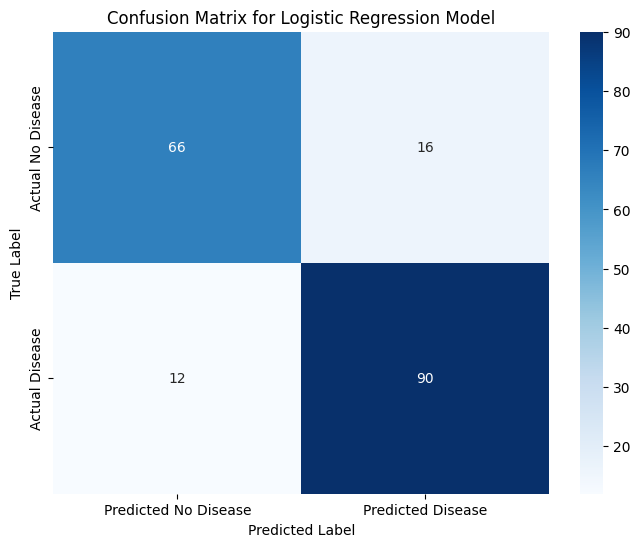

In [9]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix,
                     index=['Actual No Disease', 'Actual Disease'],
                     columns=['Predicted No Disease', 'Predicted Disease']))

print("\nClassification Report:")
print(class_report)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Disease', 'Predicted Disease'],
            yticklabels=['Actual No Disease', 'Actual Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()
